In [1]:
!gdown --folder https://drive.google.com/drive/folders/1uR3sYJASjvxu8Wx4iHyk43pkm-L-qNwn

Retrieving folder contents
Processing file 1Qo6-uR4bqnfnFkQNMkmxpVqbUxirGrVe mouth_output.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Qo6-uR4bqnfnFkQNMkmxpVqbUxirGrVe
To: /content/yawn_dataset/mouth_output.zip
100% 1.64M/1.64M [00:00<00:00, 60.6MB/s]
Download completed


In [2]:
!unzip /content/yawn_dataset/mouth_output.zip -d /content/yawn_dataset/yawn

Archive:  /content/yawn_dataset/mouth_output.zip
   creating: /content/yawn_dataset/yawn/mouth_output/
   creating: /content/yawn_dataset/yawn/mouth_output/no yawn/
  inflating: /content/yawn_dataset/yawn/mouth_output/no yawn/M_mouth_000001.jpg  
  inflating: /content/yawn_dataset/yawn/mouth_output/no yawn/M_mouth_000017.jpg  
  inflating: /content/yawn_dataset/yawn/mouth_output/no yawn/M_mouth_000033.jpg  
  inflating: /content/yawn_dataset/yawn/mouth_output/no yawn/M_mouth_000049.jpg  
  inflating: /content/yawn_dataset/yawn/mouth_output/no yawn/M_mouth_000065.jpg  
  inflating: /content/yawn_dataset/yawn/mouth_output/no yawn/M_mouth_000081.jpg  
  inflating: /content/yawn_dataset/yawn/mouth_output/no yawn/M_mouth_000097.jpg  
  inflating: /content/yawn_dataset/yawn/mouth_output/no yawn/M_mouth_000113.jpg  
  inflating: /content/yawn_dataset/yawn/mouth_output/no yawn/M_mouth_000129.jpg  
  inflating: /content/yawn_dataset/yawn/mouth_output/no yawn/M_mouth_000145.jpg  
  inflating: /c

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("davidvazquezcic/yawn-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'yawn-dataset' dataset.
Path to dataset files: /kaggle/input/yawn-dataset


In [4]:
import shutil
import os

kaggle_dataset_path = path
local_copy_path = "/content/public_dataset"

if os.path.exists(kaggle_dataset_path):
    print(f"Copying data from {kaggle_dataset_path} to {local_copy_path}...")
    shutil.copytree(kaggle_dataset_path, local_copy_path)
    print("Copy complete.")
else:
    print(f"Kaggle dataset path not found at {kaggle_dataset_path}. Please ensure the dataset was downloaded successfully.")

Copying data from /kaggle/input/yawn-dataset to /content/public_dataset...
Copy complete.


In [ ]:
def copy_files(source_dir, destination_dir):
    os.makedirs(destination_dir, exist_ok=True)

    for filename in os.listdir(source_dir):
        source_path = os.path.join(source_dir, filename)
        destination_path = os.path.join(destination_dir, filename)

        if os.path.isfile(source_path):
            shutil.copy2(source_path, destination_path)
            print(f"Copied: {filename}")

    print("All files copied successfully!")

In [6]:
# Copy private yawn dataset to all dataset directory
copy_files('/content/yawn_dataset/yawn/mouth_output/yawn', '/content/public_dataset/yawn')

# Copy private no yawn dataset to all dataset directory
copy_files('/content/yawn_dataset/yawn/mouth_output/no yawn', '/content/public_dataset/no yawn')

Copied: P_mouth_000049.jpg
Copied: P_mouth_000229.jpg
Copied: M_mouth_000109.jpg
Copied: P_mouth_000127.jpg
Copied: M_mouth_000115.jpg
Copied: M_mouth_000023.jpg
Copied: P_mouth_000025.jpg
Copied: P_mouth_000181.jpg
Copied: M_mouth_000100.jpg
Copied: P_mouth_000121.jpg
Copied: P_mouth_000001.jpg
Copied: M_mouth_000031.jpg
Copied: P_mouth_000037.jpg
Copied: P_mouth_000007.jpg
Copied: M_mouth_000043.jpg
Copied: P_mouth_000013.jpg
Copied: M_mouth_000061.jpg
Copied: P_mouth_000043.jpg
Copied: M_mouth_000001.jpg
Copied: P_mouth_000061.jpg
Copied: M_mouth_000045.jpg
Copied: P_mouth_000253.jpg
Copied: P_mouth_000187.jpg
Copied: P_mouth_000163.jpg
Copied: M_mouth_000049.jpg
Copied: P_mouth_000139.jpg
Copied: P_mouth_000223.jpg
Copied: M_mouth_000013.jpg
Copied: P_mouth_000247.jpg
Copied: P_mouth_000085.jpg
Copied: P_mouth_000217.jpg
Copied: P_mouth_000199.jpg
Copied: P_mouth_000193.jpg
Copied: P_mouth_000241.jpg
Copied: P_mouth_000103.jpg
Copied: P_mouth_000055.jpg
Copied: M_mouth_000091.jpg
C

In [ ]:
import os
import shutil
import random

SOURCE_DIR = '/content/public_dataset'
NEW_DATASET_DIR = '/content/alldataset'

MANUAL_SEED = 42
random.seed(MANUAL_SEED)

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

CLASSES = ['yawn', 'no yawn']
SPLIT_NAMES = ['train', 'test', 'val']


if abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) > 1e-6:
    print("Error: The sum of TRAIN_RATIO, VAL_RATIO, and TEST_RATIO must equal 1.0.")
    raise ValueError("Split ratios do not sum to 1.0")

print(f"Creating new directory structure in: {NEW_DATASET_DIR}")

os.makedirs(NEW_DATASET_DIR, exist_ok=True)

for split in SPLIT_NAMES:
    for class_name in CLASSES:
        path = os.path.join(NEW_DATASET_DIR, split, class_name)
        os.makedirs(path, exist_ok=True)

print("Directory structure created successfully.")

print("\n--- Starting Data Split and Copy ---")

for class_name in CLASSES:
    source_class_path = os.path.join(SOURCE_DIR, class_name)

    if not os.path.isdir(source_class_path):
        print(f"Error: Source class folder not found: {source_class_path}. Skipping.")
        continue

    all_files = [f for f in os.listdir(source_class_path) if os.path.isfile(os.path.join(source_class_path, f))]
    random.shuffle(all_files)

    total_files = len(all_files)

    train_end = int(total_files * TRAIN_RATIO)
    val_end = train_end + int(total_files * VAL_RATIO)

    train_files = all_files[:train_end]
    val_files = all_files[train_end:val_end]
    test_files = all_files[val_end:]

    print(f"\nClass: {class_name} (Total: {total_files} files)")
    print(f"  Train: {len(train_files)} files")
    print(f"  Val:   {len(val_files)} files")
    print(f"  Test:  {len(test_files)} files")

    file_map = {
        'train': train_files,
        'val': val_files,
        'test': test_files
    }

    # Copy files
    for split_name, files_to_move in file_map.items():
        dest_path = os.path.join(NEW_DATASET_DIR, split_name, class_name)

        for file_name in files_to_move:
            source_file = os.path.join(source_class_path, file_name)
            dest_file = os.path.join(dest_path, file_name)

            try:
                # Using copy to keep original data intact
                shutil.copy(source_file, dest_file)
            except Exception as e:
                print(f"Error copying file {source_file}: {e}")

print("\n✅ Data splitting and copying complete.")
print(f"New dataset is available in: {NEW_DATASET_DIR}")

Creating new directory structure in: /content/alldataset
Directory structure created successfully.

--- Starting Data Split and Copy ---

Class: yawn (Total: 2602 files)
  Train: 2081 files
  Val:   260 files
  Test:  261 files

Class: no yawn (Total: 2670 files)
  Train: 2136 files
  Val:   267 files
  Test:  267 files

✅ Data splitting and copying complete.
New dataset is available in: /content/alldataset


In [8]:
test_dir = '/content/alldataset/test'
train_dir = '/content/alldataset/train'
val_dir = '/content/alldataset/val'

In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

def to_grayscale_and_preprocess(image, label):
    image = tf.image.rgb_to_grayscale(image)
    image = tf.image.grayscale_to_rgb(image)
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(to_grayscale_and_preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(to_grayscale_and_preprocess, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(to_grayscale_and_preprocess, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("✅ Grayscale preprocessing has been successfully applied to all datasets.")

Found 4217 files belonging to 2 classes.
Found 527 files belonging to 2 classes.
Found 528 files belonging to 2 classes.
✅ Grayscale preprocessing has been successfully applied to all datasets.


In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)  # Adjust number of classes

# Build model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stop]
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

# Save model
model.save("mobilenet_finetuned.h5")

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.7743 - loss: 0.4627 - val_accuracy: 0.9393 - val_loss: 0.1977
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 778ms/step - accuracy: 0.9322 - loss: 0.1869 - val_accuracy: 0.9488 - val_loss: 0.1545
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 792ms/step - accuracy: 0.9502 - loss: 0.1476 - val_accuracy: 0.9620 - val_loss: 0.1209
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 780ms/step - accuracy: 0.9570 - loss: 0.1292 - val_accuracy: 0.9658 - val_loss: 0.1127
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 798ms/step - accuracy: 0.9652 - loss: 0.1102 - val_accuracy: 0.9488 - val_loss: 0.1418
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 779ms/step - accuracy: 0.9679 - loss: 0.1152 - val_accuracy: 0.9696 - val_loss: 0.0966
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 780ms/step - accuracy: 0.9628 - loss: 0.1087 - val_accuracy: 0.9734 - val_loss: 0.0948
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 778ms/step - accuracy: 0.9622 - loss: 0.1072 - val_accurac

Test accuracy: 0.9697


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("Generating predictions on the test set...")
y_pred_probs = model.predict(test_ds)

y_pred = (y_pred_probs > 0.5).astype(int).flatten()

y_true = []
for images, labels in test_ds:
    if labels.ndim == 1 or labels.shape[-1] == 1:
        y_true.extend(labels.numpy().flatten())

    elif labels.ndim > 1 and labels.shape[-1] > 1:
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    else:
        y_true.extend(labels.numpy())

y_true = np.array(y_true)

if len(y_pred) != len(y_true):
    print(f"\nWarning: Mismatch in lengths! True labels ({len(y_true)}) vs Predictions ({len(y_pred)})")
    min_len = min(len(y_pred), len(y_true))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]
    print(f"Truncated both to length: {min_len}")


target_names = ['Class 0 (Negative)', 'Class 1 (Positive)']
# Example for your case: ['Open Eyes / Not Yawn', 'Closed Eyes / Yawn']

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)

print(classification_report(y_true, y_pred, target_names=target_names))

print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)

cm = confusion_matrix(y_true, y_pred)
print(cm)


if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f"\nTrue Positives (TP): {tp} (Correctly predicted Class 1)")
    print(f"True Negatives (TN): {tn} (Correctly predicted Class 0)")
    print(f"False Positives (FP): {fp} (Incorrectly predicted Class 1 / Type I Error)")
    print(f"False Negatives (FN): {fn} (Incorrectly predicted Class 0 / Type II Error)")

Generating predictions on the test set...
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

Class 0 (Negative)       0.98      0.96      0.97       267
Class 1 (Positive)       0.96      0.98      0.97       261

          accuracy                           0.97       528
         macro avg       0.97      0.97      0.97       528
      weighted avg       0.97      0.97      0.97       528


CONFUSION MATRIX
[[255  12]
 [  4 257]]

True Positives (TP): 257 (Correctly predicted Class 1)
True Negatives (TN): 255 (Correctly predicted Class 0)
False Positives (FP): 12 (Incorrectly predicted Class 1 / Type I Error)
False Negatives (FN): 4 (Incorrectly predicted Class 0 / Type II Error)


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


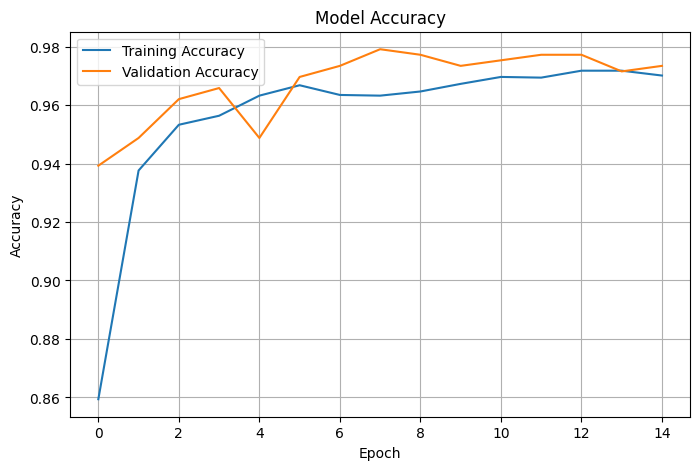

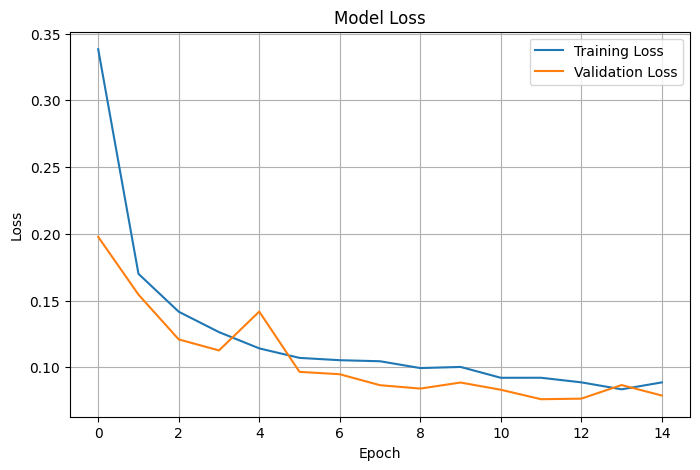

In [17]:
history_dict = history.history
print(history_dict.keys())

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_finetune = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy after fine-tuning: {test_acc:.4f}")

# Save fine-tuned model
model.save("yawn_model_finetuned.h5")

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 82s 1000ms/step - accuracy: 0.9179 - loss: 0.1924 - val_accuracy: 0.9734 - val_loss: 0.0791
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 789ms/step - accuracy: 0.9560 - loss: 0.1270 - val_accuracy: 0.9753 - val_loss: 0.0765
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 784ms/step - accuracy: 0.9647 - loss: 0.1052 - val_accuracy: 0.9772 - val_loss: 0.0732
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 791ms/step - accuracy: 0.9706 - loss: 0.0850 - val_accuracy: 0.9772 - val_loss: 0.0700
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 788ms/step - accuracy: 0.9715 - loss: 0.0862 - val_accuracy: 0.9753 - val_loss: 0.0698
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 54s 798ms/step - accuracy: 0.9752 - loss: 0.0728 - val_accuracy: 0.9810 - val_loss: 0.0646
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 787ms/step - accuracy: 0.9752 - loss: 0.0783 - val_accuracy: 0.9810 - val_loss: 0.0648
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 797ms/step - accuracy: 0.9780 - loss: 0.0629 - val_acc

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("Generating predictions on the test set...")
y_pred_probs = model.predict(test_ds)


y_pred = (y_pred_probs > 0.5).astype(int).flatten()

y_true = []
for images, labels in test_ds:
    if labels.ndim == 1 or labels.shape[-1] == 1:
        y_true.extend(labels.numpy().flatten())

    elif labels.ndim > 1 and labels.shape[-1] > 1:
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    else:
        y_true.extend(labels.numpy())

y_true = np.array(y_true)

if len(y_pred) != len(y_true):
    print(f"\nWarning: Mismatch in lengths! True labels ({len(y_true)}) vs Predictions ({len(y_pred)})")
    min_len = min(len(y_pred), len(y_true))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]
    print(f"Truncated both to length: {min_len}")


target_names = ['Class 0 (Negative)', 'Class 1 (Positive)']
# Example for your case: ['Open Eyes / Not Yawn', 'Closed Eyes / Yawn']

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)

print(classification_report(y_true, y_pred, target_names=target_names))

print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)

cm = confusion_matrix(y_true, y_pred)
print(cm)


if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f"\nTrue Positives (TP): {tp} (Correctly predicted Class 1)")
    print(f"True Negatives (TN): {tn} (Correctly predicted Class 0)")
    print(f"False Positives (FP): {fp} (Incorrectly predicted Class 1 / Type I Error)")
    print(f"False Negatives (FN): {fn} (Incorrectly predicted Class 0 / Type II Error)")

Generating predictions on the test set...
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 644ms/step

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

Class 0 (Negative)       0.99      0.98      0.99       267
Class 1 (Positive)       0.98      0.99      0.99       261

          accuracy                           0.99       528
         macro avg       0.99      0.99      0.99       528
      weighted avg       0.99      0.99      0.99       528


CONFUSION MATRIX
[[262   5]
 [  2 259]]

True Positives (TP): 259 (Correctly predicted Class 1)
True Negatives (TN): 262 (Correctly predicted Class 0)
False Positives (FP): 5 (Incorrectly predicted Class 1 / Type I Error)
False Negatives (FN): 2 (Incorrectly predicted Class 0 / Type II Error)


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


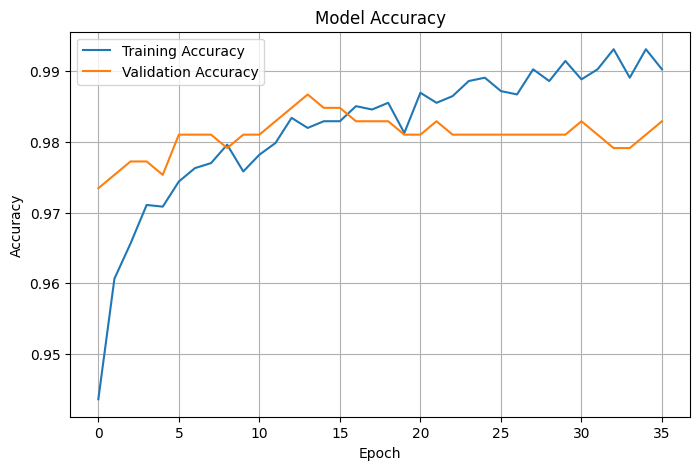

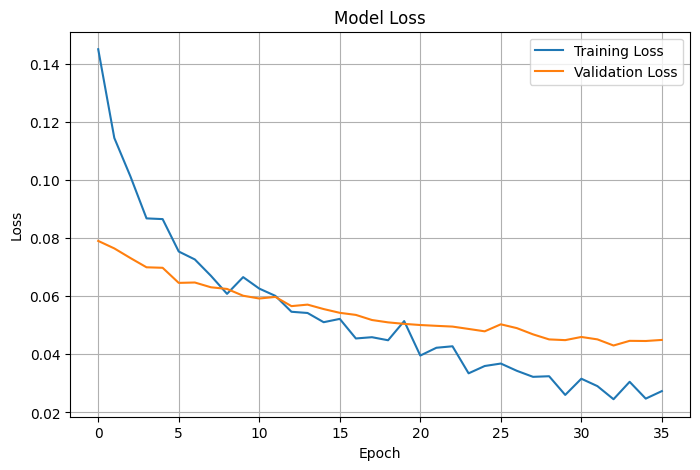

In [20]:
history_dict = history_finetune.history
print(history_dict.keys())

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()